In [114]:
import numpy as np
#loading CASCADE simulations
data = np.load (
    '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/IH scenario/OCR_IH/Accretional_Sink/OCR_IH_Nourishment_S0_Accretional_Sink.npz', allow_pickle=True)
data

NpzFile '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/IH scenario/OCR_IH/Accretional_Sink/OCR_IH_Nourishment_S0_Accretional_Sink.npz' with keys: cascade

In [115]:
cascade_object = data['cascade'][0]

In [94]:
# cascade_object.barrier3d[34].RSLR
# Get the RSLR time series from the first Barrier3D model
rslr_time_series = cascade_object.barrier3d[0].RSLR

# Calculate the cumulative sum to get total RSLR at each year
total_rslr = np.cumsum(rslr_time_series)

# Define the years you want to check
years_to_check = [24, 49, 74, 99] #-1 index

print("--- Total Sea Level Rise (m) from Simulation ---")
for year in years_to_check:
    # Python uses 0-based indexing, so we subtract 1
    index = year - 1
    if index < len(total_rslr):
        print(f"Year {year}: {total_rslr[index]:.3f} m")



--- Total Sea Level Rise (m) from Simulation ---
Year 24: 0.034 m
Year 49: 0.084 m
Year 74: 0.139 m
Year 99: 0.196 m


In [116]:
import pandas as pd
# Daily_WL_MHW = pd.read_csv('/CASCADE/scripts/FLOOD ANALYSIS/Daily_WL_MHW.csv')
Daily_WL_NAVD = pd.read_csv('/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/IH scenario/Daily_WL_NAVD.csv')

In [117]:
# Daily_WL_MHW['t'] = pd.to_datetime(Daily_WL_MHW['t'])
Daily_WL_NAVD['t'] = pd.to_datetime(Daily_WL_NAVD['t'])

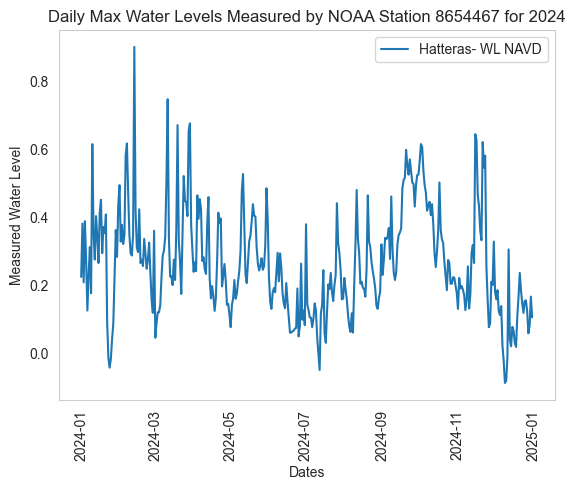

In [97]:
import matplotlib.pyplot as plt 
# plt.plot(Daily_WL_MHW['t'], Daily_WL_MHW['v'], label= 'Hatteras- WL MHW')
plt.plot(Daily_WL_NAVD['t'], Daily_WL_NAVD['v'], label= 'Hatteras- WL NAVD')

plt.xlabel('Dates')  # Rotates the label vertically
plt.ylabel('Measured Water Level')
plt.title('Daily Max Water Levels Measured by NOAA Station 8654467 for 2024')
plt.grid()
plt.legend()
plt.xticks(rotation=90)
plt.show()

In [118]:
# yesrs of interest
target_years = [24, 49, 74, 99]
# Check if the roadways is not empty
if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    # Loop through each target year
    for year in target_years:
        print(f"\n Data for Year {year}: ")    
        # Loop through each domain (roadway segment)
        for i, road_segment in enumerate(cascade_object.roadways):
            
            # Access the time series for the current road segment
            elevation_time_series = road_segment._road_ele_TS
            elevation = elevation_time_series[year]
            print(f"Domain {i}: Road Elevation = {elevation}")


 Data for Year 24: 
Domain 0: Road Elevation = 0.0
Domain 1: Road Elevation = 0.0
Domain 2: Road Elevation = 0.0
Domain 3: Road Elevation = 0.0
Domain 4: Road Elevation = 0.0
Domain 5: Road Elevation = 0.0
Domain 6: Road Elevation = 0.0
Domain 7: Road Elevation = 0.0
Domain 8: Road Elevation = 0.0
Domain 9: Road Elevation = 0.0
Domain 10: Road Elevation = 0.0
Domain 11: Road Elevation = 0.0
Domain 12: Road Elevation = 0.0
Domain 13: Road Elevation = 0.0
Domain 14: Road Elevation = 0.0
Domain 15: Road Elevation = 1.1061687699615925
Domain 16: Road Elevation = 1.1061687699615925
Domain 17: Road Elevation = 1.1061687699615925
Domain 18: Road Elevation = 1.1061687699615925
Domain 19: Road Elevation = 1.1061687699615925
Domain 20: Road Elevation = 1.1061687699615925
Domain 21: Road Elevation = 1.1061687699615925
Domain 22: Road Elevation = 1.1061687699615925
Domain 23: Road Elevation = 1.1061687699615925
Domain 24: Road Elevation = 1.1061687699615925
Domain 25: Road Elevation = 1.106168769

In [119]:
#exporting road elevations for aech domain categorized by the years

results_list = []
target_years = [24, 49, 74, 99]

if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    for year in target_years:
        for i, road_segment in enumerate(cascade_object.roadways):
            elevation_time_series = road_segment._road_ele_TS
            
            if year < len(elevation_time_series):
                elevation = elevation_time_series[year]
                
                result_row = {
                    'Year': year,
                    'Domain': i,
                    'Road_Elevation': elevation
                }
                results_list.append(result_row)
                
            else:
                print(f"Data for Year {year}, Domain {i} is not available.")

#convert the list to a DataFrame and save it
if results_list:
    # Convert the list of dictionaries into a pandas DataFrame
    results_df = pd.DataFrame(results_list)
    output_filename = 'OCR_IH_Nourishment_S0_Accretional_Sink_roadelevation.csv'

    results_df.to_csv(output_filename, index=False)
    print(results_df.head()) 


   Year  Domain  Road_Elevation
0    24       0             0.0
1    24       1             0.0
2    24       2             0.0
3    24       3             0.0
4    24       4             0.0


In [120]:
#load the csv files for road elvation and water level
road_elevation = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/IH scenario/OCR_IH/Accretional_Sink/OCR_IH_Nourishment_S0_Accretional_Sink_roadelevation.csv'
water_level_NAVD = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/IH scenario/Daily_WL_NAVD.csv'
road_df = pd.read_csv(road_elevation)
water_NAVD_df = pd.read_csv(water_level_NAVD)


In [121]:
#daily max water level (NAVD)
daily_tidal_levels_NAVD= water_NAVD_df['v'].values
daily_tidal_levels_NAVD

array([ 0.225,  0.382,  0.209,  0.389,  0.274,  0.126,  0.23 ,  0.313,
        0.177,  0.616,  0.355,  0.276,  0.404,  0.344,  0.266,  0.414,
        0.452,  0.295,  0.372,  0.354,  0.409,  0.093, -0.013, -0.042,
       -0.016,  0.042,  0.089,  0.228,  0.363,  0.284,  0.435,  0.495,
        0.329,  0.378,  0.322,  0.349,  0.584,  0.618,  0.475,  0.35 ,
        0.295,  0.288,  0.348,  0.902,  0.421,  0.312,  0.298,  0.424,
        0.266,  0.276,  0.257,  0.337,  0.291,  0.249,  0.276,  0.326,
        0.237,  0.157,  0.119,  0.361,  0.046,  0.09 ,  0.121,  0.121,
        0.142,  0.224,  0.288,  0.303,  0.343,  0.508,  0.748,  0.34 ,
        0.226,  0.227,  0.201,  0.276,  0.216,  0.365,  0.672,  0.331,
        0.271,  0.175,  0.343,  0.522,  0.449,  0.445,  0.404,  0.654,
        0.677,  0.379,  0.305,  0.24 ,  0.268,  0.242,  0.465,  0.396,
        0.454,  0.424,  0.272,  0.283,  0.248,  0.234,  0.379,  0.46 ,
        0.22 ,  0.162,  0.198,  0.167,  0.125,  0.162,  0.269,  0.414,
      

In [122]:
#subtractibg NAVD and constant 0.26 (MHW) 
daily_tidal_MHW = daily_tidal_levels_NAVD - 0.26
daily_tidal_MHW

array([-0.035,  0.122, -0.051,  0.129,  0.014, -0.134, -0.03 ,  0.053,
       -0.083,  0.356,  0.095,  0.016,  0.144,  0.084,  0.006,  0.154,
        0.192,  0.035,  0.112,  0.094,  0.149, -0.167, -0.273, -0.302,
       -0.276, -0.218, -0.171, -0.032,  0.103,  0.024,  0.175,  0.235,
        0.069,  0.118,  0.062,  0.089,  0.324,  0.358,  0.215,  0.09 ,
        0.035,  0.028,  0.088,  0.642,  0.161,  0.052,  0.038,  0.164,
        0.006,  0.016, -0.003,  0.077,  0.031, -0.011,  0.016,  0.066,
       -0.023, -0.103, -0.141,  0.101, -0.214, -0.17 , -0.139, -0.139,
       -0.118, -0.036,  0.028,  0.043,  0.083,  0.248,  0.488,  0.08 ,
       -0.034, -0.033, -0.059,  0.016, -0.044,  0.105,  0.412,  0.071,
        0.011, -0.085,  0.083,  0.262,  0.189,  0.185,  0.144,  0.394,
        0.417,  0.119,  0.045, -0.02 ,  0.008, -0.018,  0.205,  0.136,
        0.194,  0.164,  0.012,  0.023, -0.012, -0.026,  0.119,  0.2  ,
       -0.04 , -0.098, -0.062, -0.093, -0.135, -0.098,  0.009,  0.154,
      

In [123]:
#comparing road elevations only with tidal water levels
for index, road_row in road_df.iterrows():
        
        # Get the specific data from the current row
        year = int(road_row['Year'])
        domain = int(road_row['Domain'])
        road_elevation = road_row['Road_Elevation']
        
        # compare directly against the single array of 365 daily levels.
        is_flooded = road_elevation < daily_tidal_MHW
        
        # Count how many days the road was flooded
        flooded_days_count = np.sum(is_flooded)
        
        total_days_in_data = len(daily_tidal_MHW)
        
        print(f"Year {year}, Domain {domain} (Road Elev: {road_elevation:.2f}m): Flooded on {flooded_days_count} out of {total_days_in_data} days.")


Year 24, Domain 0 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 1 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 2 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 3 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 4 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 5 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 6 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 7 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 8 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 9 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 10 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 11 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 12 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 13 (Road Elev: 0.00m): Flooded on 172 out of 366 days.
Year 24, Domain 

In [70]:
# looking into SLR values in the model
slr_rate = cascade_object._sea_level_rise_rate
is_slr_constant = cascade_object._slr_constant

print(f"Sea-Level Rise Rate (_sea_level_rise_rate): {slr_rate} m/yr")
print(f"Is Sea-Level Rise Constant? (_slr_constant): {is_slr_constant}")

Sea-Level Rise Rate (_sea_level_rise_rate): 0.0056 m/yr
Is Sea-Level Rise Constant? (_slr_constant): True



 Loading data and running analysis:
Successfully loaded all input files (skipped header in water level file).
Analysis complete. Results saved to 'OCR_IH_Natural_S0_Accretional_Sink_flood.csv'
  > Plot saved as 'Heatmap_OCR_IH_Natural_S0_Accretional_Sink.png'


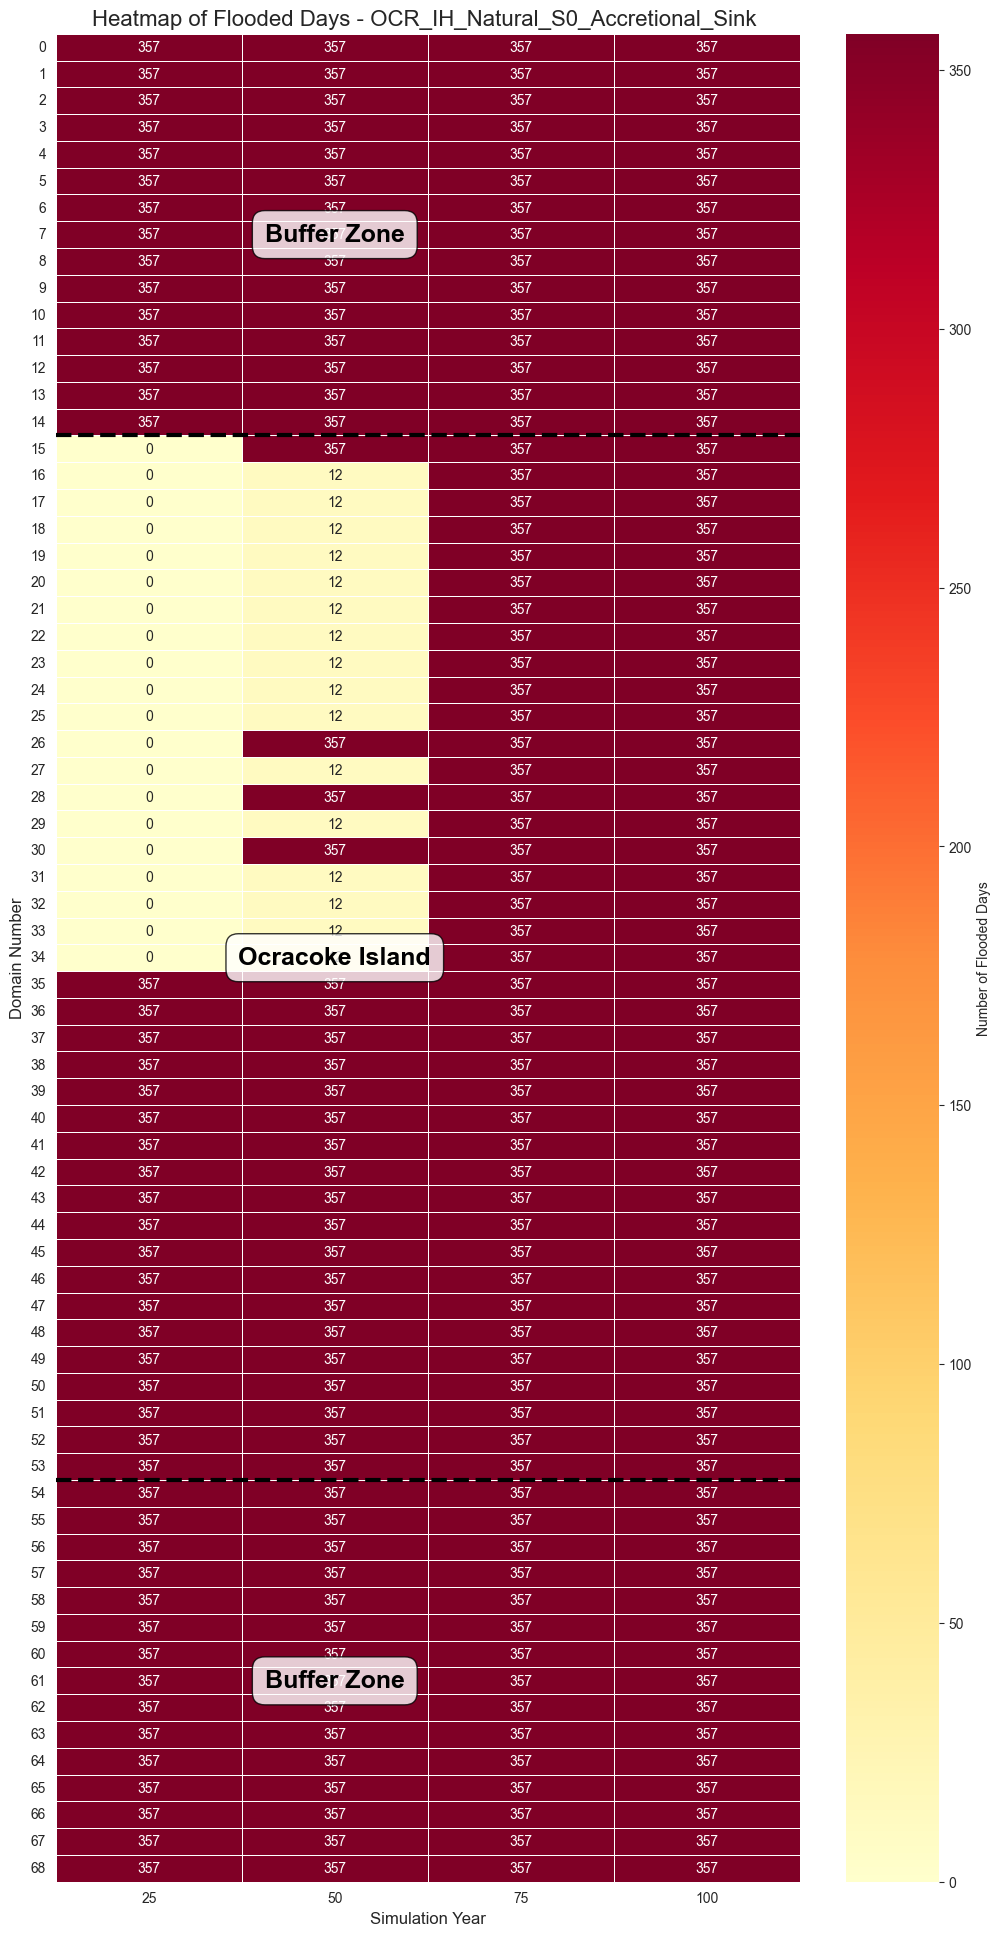

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#read the road elev and tidal water levels and specify a file name to output

analysis_output_filepath = 'OCR_IH_Nourishment_S0_Accretional_Sink_flood.csv'
MHW_ELEVATION_NAVD88 = 0.26  # The MHW value for your site in meters NAVD88
print(f"\n Loading data and running analysis:")
part1_success = False
results_df = None
print("Successfully loaded all input files (skipped header in water level file).")

# Perform the comparison
final_results = []
for index, road_row in road_df.iterrows():
    year = int(road_row['Year'])
    domain = int(road_row['Domain'])
    road_elevation = road_row['Road_Elevation']
    flooded_days = np.sum(road_elevation < daily_tidal_MHW)
    
    result_row = {
        'Year': year,
        'Domain': domain,
        'Road_Elevation_m': road_elevation,
        'Flooded_Days': flooded_days,
    }
    final_results.append(result_row)

# Save the analysis results to a CSV file

results_df = pd.DataFrame(final_results)
results_df.to_csv(analysis_output_filepath, index=False)
print(f"Analysis complete. Results saved to '{analysis_output_filepath}'")

heatmap_data = results_df.pivot_table(index='Domain', columns='Year', values='Flooded_Days')

plt.figure(figsize=(12, 24))
sns.set_style("whitegrid")
ax = sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='YlOrRd', linewidths=.5, cbar_kws={'label': 'Number of Flooded Days'})

ax.axhline(y=15, color='black', linestyle='--', linewidth=3)
ax.axhline(y=54, color='black', linestyle='--', linewidth=3)
ax.set_xticklabels(['25', '50', '75', '100'])

text_props = dict(ha='center', va='center', fontsize=18, color='black', weight='bold')
bbox_props = dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1, alpha=0.8)

plt.text(1.5, 7.5, 'Buffer Zone', **text_props, bbox=bbox_props)
plt.text(1.5, 34.5, 'Ocracoke Island', **text_props, bbox=bbox_props)
plt.text(1.5, 61.5, 'Buffer Zone', **text_props, bbox=bbox_props)



plt.title(f'Heatmap of Flooded Days - OCR_IH_Natural_S0_Accretional_Sink ', fontsize=16)
plt.xlabel('Simulation Year', fontsize=12)
plt.ylabel('Domain Number', fontsize=12)
plt.yticks(rotation=0)

plot_output_filename = f'Heatmap_OCR_IH_Natural_S0_Accretional_Sink.png'
plt.savefig(plot_output_filename, bbox_inches='tight')
print(f"  > Plot saved as '{plot_output_filename}'")
plt.show() # Close the figure to avoid displaying multiple plots at once
